In [1]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import os
import sys

parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

In [ ]:
from src.rocket import Rocket
from Deliverable_3_1.MPCVelControl import MPCVelControl
import numpy as np
from src.vel_rocket_vis import RocketVis
import matplotlib.pyplot as plt

# Rocket
Ts = 1.0 / 20.0
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
H = 3.0
mpc = MPCVelControl().new_controller(rocket, Ts, H)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



### Terminal invariant set

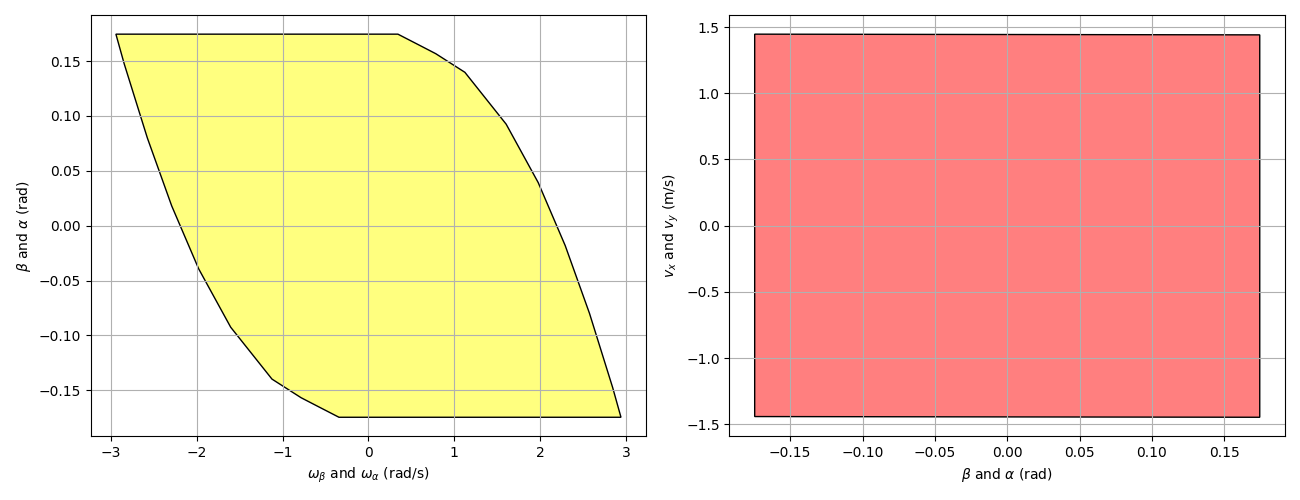

In [4]:
plt.close('all')
plt.figure('Terminal invariant set for x and y subsystems', (13, 5))

ax = plt.subplot(121)
mpc.mpc_x.O_inf.projection((0, 1)).plot(ax, color='yellow', opacity=0.5)
plt.xlabel(r'$\omega_\beta$ and $\omega_\alpha$ (rad/s)')
plt.ylabel(r'$\beta$ and $\alpha$ (rad)')
plt.grid()

ax = plt.subplot(122)
mpc.mpc_x.O_inf.projection((1, 2)).plot(ax, color='red', opacity=0.5)
plt.xlabel(r'$\beta$ and $\alpha$ (rad)')
plt.ylabel(r'$v_x$ and $v_y$ (m/s)')
plt.grid()

plt.tight_layout()
plt.show()

### First case : 5 m/s in x, y, z

In [5]:
# Initial state
t0 = 0.0
x0 = np.array([
    0.0, 0.0, 0.0,	# omega
    0.0, 0.0, 0.0,	# r
    5.0, 5.0, 5.0,	# v
    0.0, 0.0, 0.0	# p
])
u0 = mpc.us

# Closed loop simulation
sim_time = 7.0
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, _ = rocket.simulate_control(
    mpc, sim_time, H, x0, method="linear"
)

Simulating time 0.00: 

c:\Users\killi\Desktop\MPC-Course-EPFL\.env\Lib\site-packages\cvxpy\reductions\solvers\solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(



Simulating time 0.05: 
Simulating time 0.10: 
Simulating time 0.15: 
Simulating time 0.20: 
Simulating time 0.25: 
Simulating time 0.30: 
Simulating time 0.35: 
Simulating time 0.40: 
Simulating time 0.45: 
Simulating time 0.50: 
Simulating time 0.55: 
Simulating time 0.60: 
Simulating time 0.65: 
Simulating time 0.70: 
Simulating time 0.75: 
Simulating time 0.80: 
Simulating time 0.85: 
Simulating time 0.90: 
Simulating time 0.95: 
Simulating time 1.00: 
Simulating time 1.05: 
Simulating time 1.10: 
Simulating time 1.15: 
Simulating time 1.20: 
Simulating time 1.25: 
Simulating time 1.30: 
Simulating time 1.35: 
Simulating time 1.40: 
Simulating time 1.45: 
Simulating time 1.50: 
Simulating time 1.55: 
Simulating time 1.60: 
Simulating time 1.65: 
Simulating time 1.70: 
Simulating time 1.75: 
Simulating time 1.80: 
Simulating time 1.85: 
Simulating time 1.90: 
Simulating time 1.95: 
Simulating time 2.00: 
Simulating time 2.05: 
Simulating time 2.10: 
Simulating time 2.15: 
Simulating

In [7]:
# Visualize simulation
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:, :-1], u_cl, T_ol=t_ol[..., :-1], X_ol=x_ol, U_ol=u_ol)

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=139, step=2), IntSlider(value=0…

{'fig': <Figure size 640x480 with 16 Axes>,
 'axes': [<Axes: ylabel='inputs'>,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Y'}>,
  <Axes: title={'center': 'Subsystem X'}, ylabel='$\\omega_{\\alpha\\beta\\gamma}$ (deg/s)'>,
  <Axes: title={'center': 'Subsystem Roll'}>,
  <Axes: >,
  <Axes: ylabel='$\\alpha\\beta\\gamma$ (deg)'>,
  <Axes: >,
  <Axes: ylabel='$v$ (m/s)'>,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Z'}>,
  <Axes: ylabel='$\\text{pos}$ (m)'>,
  <Axes: >,
  <Axes: >],
 'plotter': <pyvista.plotting.plotter.Plotter at 0x178ba5c9a90>,
 'scene_objects': {'rocket_actor': Actor (0x178ba4b02e0)
    Center:                     (0.32006999999999997, -0.0015085000000000237, 0.5884844999999999)
    Pickable:                   True
    Position:                   (0.0, 0.0, 0.0)
    Scale:                      (1.0, 1.0, 1.0)
    Visible:                    True
    X Bounds                    -6.402E-01, 1.280E+00
    Y Bounds                    -1.21

In [ ]:
plt.close('all')
plt.figure('5 ms in x, y, z', (13, 5))

# x subsystem

plt.subplot(4, 4, 1)
plt.title('x subsystem')
plt.plot(t_cl[:-1], np.rad2deg(x_cl[1, :-1]))
plt.ylabel(r'$\omega_\beta$ (°/s)')
plt.grid()

plt.subplot(4, 4, 5)
plt.plot(t_cl[:-1], np.rad2deg(x_cl[4, :-1]))
plt.ylabel(r'$\beta$ (°)')
plt.grid()

plt.subplot(4, 4, 9)
plt.plot(t_cl[:-1], x_cl[6, :-1])
plt.ylabel(r'$v_x$ (m/s)')
plt.grid()

plt.subplot(4, 4, 13)
plt.plot(t_cl[:-1], np.rad2deg(u_cl[1, :]))
plt.xlabel(r'$t$ (s)')
plt.ylabel(r'$\delta_2$ (°)')
plt.grid()

# y subsystem

plt.subplot(4, 4, 2)
plt.title('y subsystem')
plt.plot(t_cl[:-1], np.rad2deg(x_cl[0, :-1]))
plt.ylabel(r'$\omega_\alpha$ (°/s)')
plt.grid()

plt.subplot(4, 4, 6)
plt.plot(t_cl[:-1], np.rad2deg(x_cl[3, :-1]))
plt.ylabel(r'$\alpha$ (°)')
plt.grid()

plt.subplot(4, 4, 10)
plt.plot(t_cl[:-1], x_cl[4, :-1])
plt.ylabel(r'$v_y$ (m/s)')
plt.grid()

plt.subplot(4, 4, 14)
plt.plot(t_cl[:-1], np.rad2deg(u_cl[0, :]))
plt.xlabel(r'$t$ (s)')
plt.ylabel(r'$\delta_1$ (°)')
plt.grid()

# z subsystem

plt.subplot(4, 4, 3)
plt.title('z subsystem')
plt.plot(t_cl[:-1], x_cl[8, :-1])
plt.ylabel(r'$v_z$ (m/s)')
plt.grid()

plt.subplot(4, 4, 7)
plt.plot(t_cl[:-1], u_cl[2, :])
plt.xlabel(r'$t$ (s)')
plt.ylabel(r'$P_\text{avg}$ (%)')
plt.grid()

# roll subsystem

plt.subplot(4, 4, 4)
plt.title('roll subsystem')
plt.plot(t_cl[:-1], np.rad2deg(x_cl[2, :-1]))
plt.ylabel(r'$\omega_\gamma$ (°/s)')
plt.grid()

plt.subplot(4, 4, 8)
plt.plot(t_cl[:-1], np.rad2deg(x_cl[5, :-1]))
plt.ylabel(r'$\gamma$ (°)')
plt.grid()

plt.subplot(4, 4, 12)
plt.plot(t_cl[:-1], u_cl[3, :])
plt.xlabel(r'$t$ (s)')
plt.ylabel(r'$P_\text{diff}$ (%)')
plt.grid()

plt.tight_layout()
plt.show()

### Second case : 30° roll angle

In [ ]:
# Initial state
t0 = 0.0
x0 = np.array([
    0.0, 0.0, 0.0,	# omega
    0.0, 0.0, np.deg2rad(30),	# r
    0.0, 0.0, 0.0,	# v
    0.0, 0.0, 0.0	# p
])
u0 = mpc.us

# Closed loop simulation
sim_time = 7.0
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, _ = rocket.simulate_control(
    mpc, sim_time, H, x0, method="linear"
)

In [ ]:
# Visualize simulation
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:, :-1], u_cl, T_ol=t_ol[..., :-1], X_ol=x_ol, U_ol=u_ol)

In [ ]:
plt.close('all')
plt.figure('30° roll', (13, 5))

# x subsystem

plt.subplot(4, 4, 1)
plt.title('x subsystem')
plt.plot(t_cl[:-1], np.rad2deg(x_cl[1, :-1]))
plt.ylabel(r'$\omega_\beta$ (°/s)')
plt.grid()

plt.subplot(4, 4, 5)
plt.plot(t_cl[:-1], np.rad2deg(x_cl[4, :-1]))
plt.ylabel(r'$\beta$ (°)')
plt.grid()

plt.subplot(4, 4, 9)
plt.plot(t_cl[:-1], x_cl[6, :-1])
plt.ylabel(r'$v_x$ (m/s)')
plt.grid()

plt.subplot(4, 4, 13)
plt.plot(t_cl[:-1], np.rad2deg(u_cl[1, :]))
plt.xlabel(r'$t$ (s)')
plt.ylabel(r'$\delta_2$ (°)')
plt.grid()

# y subsystem

plt.subplot(4, 4, 2)
plt.title('y subsystem')
plt.plot(t_cl[:-1], np.rad2deg(x_cl[0, :-1]))
plt.ylabel(r'$\omega_\alpha$ (°/s)')
plt.grid()

plt.subplot(4, 4, 6)
plt.plot(t_cl[:-1], np.rad2deg(x_cl[3, :-1]))
plt.ylabel(r'$\alpha$ (°)')
plt.grid()

plt.subplot(4, 4, 10)
plt.plot(t_cl[:-1], x_cl[4, :-1])
plt.ylabel(r'$v_y$ (m/s)')
plt.grid()

plt.subplot(4, 4, 14)
plt.plot(t_cl[:-1], np.rad2deg(u_cl[0, :]))
plt.xlabel(r'$t$ (s)')
plt.ylabel(r'$\delta_1$ (°)')
plt.grid()

# z subsystem

plt.subplot(4, 4, 3)
plt.title('z subsystem')
plt.plot(t_cl[:-1], x_cl[8, :-1])
plt.ylabel(r'$v_z$ (m/s)')
plt.grid()

plt.subplot(4, 4, 7)
plt.plot(t_cl[:-1], u_cl[2, :])
plt.xlabel(r'$t$ (s)')
plt.ylabel(r'$P_\text{avg}$ (%)')
plt.grid()

# roll subsystem

plt.subplot(4, 4, 4)
plt.title('roll subsystem')
plt.plot(t_cl[:-1], np.rad2deg(x_cl[2, :-1]))
plt.ylabel(r'$\omega_\gamma$ (°/s)')
plt.grid()

plt.subplot(4, 4, 8)
plt.plot(t_cl[:-1], np.rad2deg(x_cl[5, :-1]))
plt.ylabel(r'$\gamma$ (°)')
plt.grid()

plt.subplot(4, 4, 12)
plt.plot(t_cl[:-1], u_cl[3, :])
plt.xlabel(r'$t$ (s)')
plt.ylabel(r'$P_\text{diff}$ (%)')
plt.grid()

plt.tight_layout()
plt.show()